In [1]:
import requests
import pandas as pd
import time
import os
from pathlib import Path
import boto3, json

if Path.cwd().name == "notebooks":
    os.chdir("..")

from src.config import load_config

CONFIG = load_config()

### Droits pour l'utilisateur admin
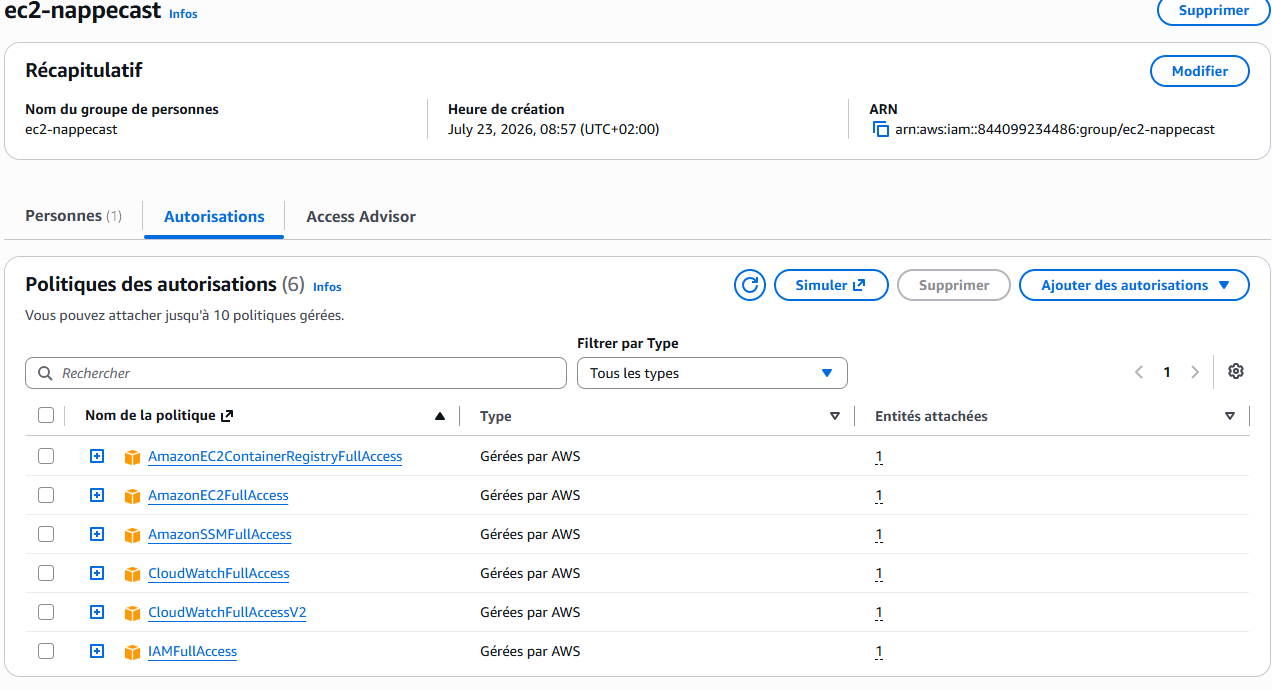

### Création de l'autorité IAM

In [ ]:

iam         =  boto3.client("iam", region_name="eu-west-3")
role_name   = "nappecast-ec2-role"
profil_name = "nappecast-ec2-profil"
group_name  = "nappecast-ec2-group"
key_name      = "nappecast-ec2-key"

### Création du rôle (EC2<>S3)

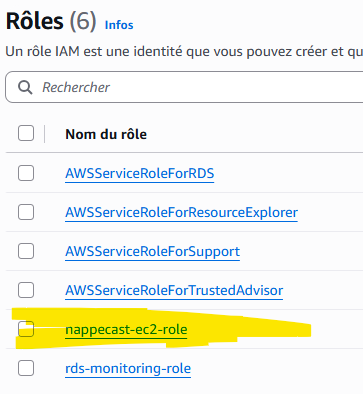

In [ ]:
# policy
trust_policy = {
    "Version": "2012-10-17",
    "Statement": [{"Effect": "Allow", "Principal": {"Service": "ec2.amazonaws.com"}, "Action": "sts:AssumeRole"}]
}

# Rôle 
iam.create_role(RoleName=role_name, AssumeRolePolicyDocument=json.dumps(trust_policy))
iam.attach_role_policy(RoleName=role_name, PolicyArn="arn:aws:iam::aws:policy/AmazonEC2ContainerRegistryReadOnly")
iam.attach_role_policy(RoleName=role_name, PolicyArn="arn:aws:iam::aws:policy/AmazonSSMManagedInstanceCore")
iam.attach_role_policy(RoleName=role_name, PolicyArn="arn:aws:iam::aws:policy/AmazonS3FullAccess")

# Relation Instance / rôle
iam.create_instance_profile(InstanceProfileName=profil_name)
iam.add_role_to_instance_profile(InstanceProfileName=profil_name, RoleName=role_name)

### Groupe de sécurité EC2 pour l'utilisation des ports entre streamlit et API

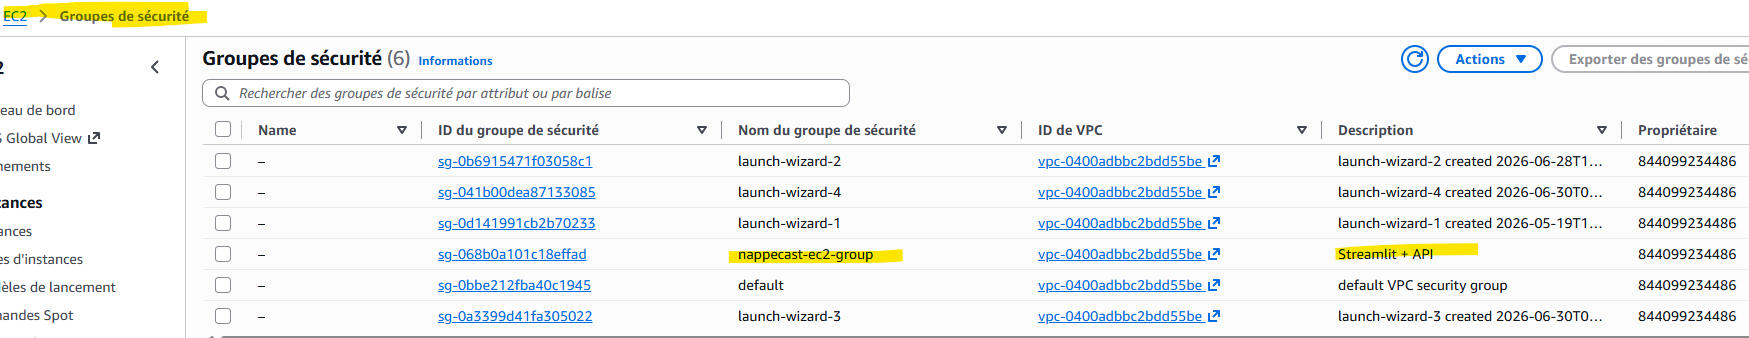

In [ ]:
ec2 = boto3.client("ec2", region_name="eu-west-3")
import requests
my_ip = requests.get("https://checkip.amazonaws.com").text.strip()

vpc_id = ec2.describe_vpcs(Filters=[{"Name": "is-default", "Values": ["true"]}])["Vpcs"][0]["VpcId"]
sg = ec2.create_security_group(GroupName="nappecast-sg", Description="Streamlit + API", VpcId=vpc_id)
sg_id = sg["GroupId"]

ec2.authorize_security_group_ingress(
    GroupId=sg_id,
    IpPermissions=[
        {"IpProtocol": "tcp", "FromPort": 22, "ToPort": 22, "IpRanges": [{"CidrIp": f"{my_ip}/32"}]},
        {"IpProtocol": "tcp", "FromPort": 80, "ToPort": 80, "IpRanges": [{"CidrIp": "0.0.0.0/0"}]},
        {"IpProtocol": "tcp", "FromPort": 443, "ToPort": 443, "IpRanges": [{"CidrIp": "0.0.0.0/0"}]},
    ],
)

### Création de l'instance EC2 & installation docker

In [3]:
ssm = boto3.client("ssm", region_name="eu-west-3")
ami_id = ssm.get_parameter(Name="/aws/service/ami-amazon-linux-latest/al2023-ami-kernel-default-x86_64")["Parameter"]["Value"]

user_data = """#!/bin/bash
yum update -y

# Docker (paquet natif Amazon Linux 2023)
yum install -y docker
systemctl enable docker
systemctl start docker

mkdir -p /usr/local/lib/docker/cli-plugins

# Docker Compose v2 (binaire, le dépôt Docker CE n'est pas compatible AL2023)
curl -SL https://github.com/docker/compose/releases/latest/download/docker-compose-linux-x86_64 \
  -o /usr/local/lib/docker/cli-plugins/docker-compose
chmod +x /usr/local/lib/docker/cli-plugins/docker-compose

# Docker Buildx (nécessaire pour "docker compose build")
BUILDX_URL=$(curl -s https://api.github.com/repos/docker/buildx/releases/latest \
  | grep "browser_download_url.*linux-amd64\\"" \
  | cut -d '"' -f 4 \
  | head -n 1)
curl -SL "$BUILDX_URL" -o /usr/local/lib/docker/cli-plugins/docker-buildx
chmod +x /usr/local/lib/docker/cli-plugins/docker-buildx

# Python + boto3 (pour récupérer les fichiers depuis S3 sans AWS CLI)
yum install -y python3-pip
pip3 install boto3
"""

""# clé de sécurité SSH
response = ec2.create_key_pair(KeyName=key_name)
with open(f"{key_name}.pem", "w") as f:
    f.write(response["KeyMaterial"])
os.chmod(f"{key_name}.pem", 0o400)
""
# Création de l'instance
resp = ec2.run_instances(
    ImageId=ami_id,
    InstanceType="t3.micro",
    SecurityGroupIds=[sg_id],
    KeyName=key_name,
    IamInstanceProfile={"Name": profil_name},
    UserData=user_data,
    MinCount=1, MaxCount=1,
    TagSpecifications=[{"ResourceType": "instance", "Tags": [{"Key": "Name", "Value": "app-server"}]}],
)
instance_id = resp["Instances"][0]["InstanceId"]

NameError: name 'ec2' is not defined

In [ ]:
# IP Elastic pour un domaine fixe
alloc = ec2.allocate_address(Domain="vpc")
ec2.associate_address(InstanceId=instance_id, AllocationId=alloc["AllocationId"])
print(alloc["PublicIp"])

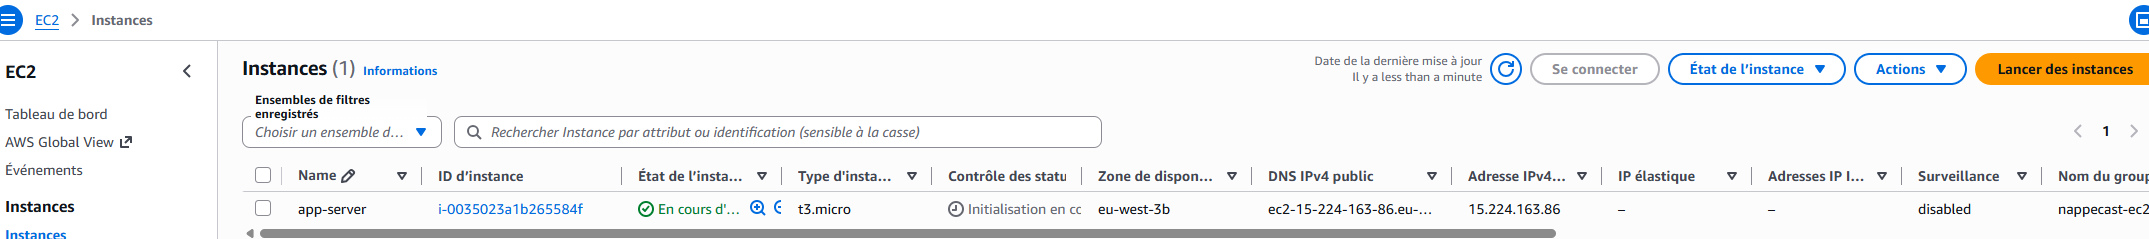

### Upload des fichiers vers l'instanec S3

In [ ]:
s3_session = boto3.Session()
s3 = s3_session.client("s3")

import os
from pathlib import Path

EXCLUDE_DIRS = {".git", "__pycache__", ".venv", "node_modules"}
EXCLUDE_FILES = {".env"}

project_root = Path("..").resolve() / "NappeCast"   # depuis notebook/, remonte à la racine du projet

def upload_path(s3_client, path: Path, bucket, s3_prefix, base: Path):
    if not path.exists():
        print(f"⚠️  Introuvable, ignoré : {path}")
        return
    if path.is_file():
        relative = path.relative_to(base).as_posix()
        print(f"Upload : {path} -> s3://{bucket}/{s3_prefix}/{relative}")
        s3_client.upload_file(str(path), bucket, f"{s3_prefix}/{relative}")
    elif path.is_dir():
        for root, dirs, files in os.walk(path):
            dirs[:] = [d for d in dirs if d not in EXCLUDE_DIRS]
            for file in files:
                if file in EXCLUDE_FILES:
                    continue
                local_file = Path(root) / file
                relative = local_file.relative_to(base).as_posix()
                print(f"Upload : {local_file} -> s3://{bucket}/{s3_prefix}/{relative}")
                s3_client.upload_file(str(local_file), bucket, f"{s3_prefix}/{relative}")

# uniquement ce qu'on veut déployer, pas tout le projet ni le dossier notebook/
to_upload = [
    project_root / "docker-compose.yml",
    project_root / "Caddyfile", 
    project_root / "src",
    project_root / "configs",
]

for item in to_upload:
    upload_path(s3, item, "nappecast", "app", base=project_root)

Upload : /home/ronanguilloueee/NappeCast/docker-compose.yml -> s3://nappecast/app/docker-compose.yml
Upload : /home/ronanguilloueee/NappeCast/Caddyfile -> s3://nappecast/app/Caddyfile
Upload : /home/ronanguilloueee/NappeCast/src/config.py -> s3://nappecast/app/src/config.py
Upload : /home/ronanguilloueee/NappeCast/src/__init__.py -> s3://nappecast/app/src/__init__.py
Upload : /home/ronanguilloueee/NappeCast/src/helper/aws.py -> s3://nappecast/app/src/helper/aws.py
Upload : /home/ronanguilloueee/NappeCast/src/helper/data.py -> s3://nappecast/app/src/helper/data.py
Upload : /home/ronanguilloueee/NappeCast/src/helper/__init__.py -> s3://nappecast/app/src/helper/__init__.py
Upload : /home/ronanguilloueee/NappeCast/src/mlflow/docker-compose.yml -> s3://nappecast/app/src/mlflow/docker-compose.yml
Upload : /home/ronanguilloueee/NappeCast/src/mlflow/Dockerfile -> s3://nappecast/app/src/mlflow/Dockerfile
Upload : /home/ronanguilloueee/NappeCast/src/app/app_predictions.py -> s3://nappecast/app/s

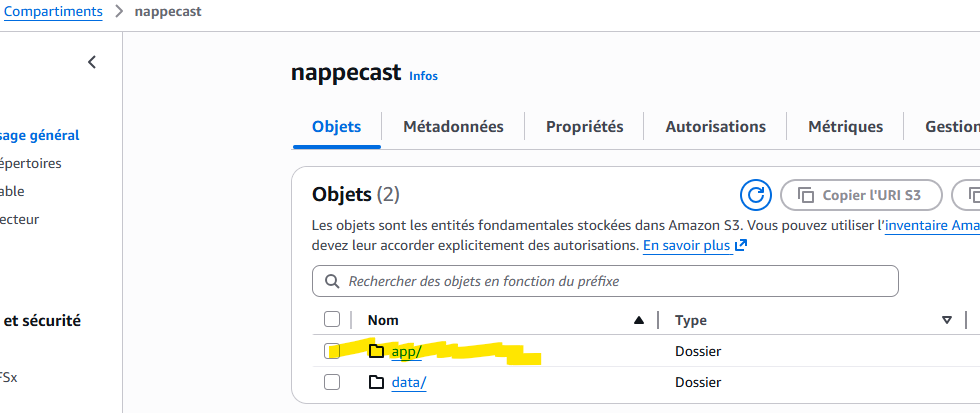

### Transfert vers EC2
# connexion SSH
ssh -i "nappecast-ec2-key.pem" ec2-user@ec2-51-45-21-195.eu-west-3.compute.amazonaws.com

#### Installation des packages
#!/bin/bash
set -e

# Mise à jour du système
sudo yum update -y

# Docker (paquet natif Amazon Linux 2023, pas besoin du dépôt Docker CE)
sudo yum install -y docker
sudo systemctl enable docker
sudo systemctl start docker

# Vérifications
docker --version
docker compose version
python3 -c "import boto3; print('boto3 OK', boto3.__version__)"

#### Copie des fichiers vers EC2
cat > /home/ec2-user/download_s3.py << 'EOF'
import boto3, os

s3 = boto3.client("s3", region_name="eu-west-3")
bucket = "nappecast"
prefix = "app/"
local_dir = "/home/ec2-user/app"

paginator = s3.get_paginator("list_objects_v2")
for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
    for obj in page.get("Contents", []):
        key = obj["Key"]
        relative_path = key[len(prefix):]
        if not relative_path:
            continue
        local_path = os.path.join(local_dir, relative_path)
        os.makedirs(os.path.dirname(local_path), exist_ok=True)
        s3.download_file(bucket, key, local_path)
        print(f"Téléchargé : {key} -> {local_path}")
EOF

python3 /home/ec2-user/download_s3.py

### Lancement de docker compose

- cd /home/ec2-user/app
- sudo docker compose up -d --build

#### vérifie que le conteneur tourne 
- sudo docker compose ps

### nettoyer le cache docker
udo docker system prune -a -f

### pour mettre à jour un fichier sur EC2 depuis S3
# upload sur S3
upload_path(s3, project_root / "src" / "app" / "requirements.txt", "nappecast", "app", base=project_root)

# bash  > transfert vers EC2 et build docker
python3 /home/ec2-user/download_s3.py
cd /home/ec2-user/app
sudo docker compose up -d --build

In [ ]:
# Arret de l'instance

ec2.stop_instances(InstanceIds=[instance_id])
print("Arrêt en cours...")

ec2.get_waiter("instance_stopped").wait(InstanceIds=[instance_id])
print("Instance arrêtée.")

### restart le SSH en cas de pb

In [ ]:

from dotenv import load_dotenv, find_dotenv
import os, boto3

load_dotenv(find_dotenv())

ec2_session = boto3.Session(
    aws_access_key_id=os.getenv("ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("SECRET_ACCESS_KEY"),
    region_name="eu-west-3",
)
ec2 = ec2_session.client("ec2")
ssm = ec2_session.client("ssm")

resp = ec2.describe_instances(
    Filters=[
        {"Name": "tag:Name", "Values": ["app-server"]},
        {"Name": "instance-state-name", "Values": ["running", "stopped"]},
    ]
)
instance_id = resp["Reservations"][0]["Instances"][0]["InstanceId"]
ssm = ec2_session.client("ssm", region_name="eu-west-3")

response = ssm.send_command(
    InstanceIds=[instance_id],
    DocumentName="AWS-RunShellScript",
    Parameters={"commands": [
        "systemctl status sshd || true",
        "systemctl restart sshd",
        "free -h",
        "sudo docker stats --no-stream",
    ]},
)

command_id = response["Command"]["CommandId"]

# etat du SSH
import time
time.sleep(5)
result = ssm.get_command_invocation(CommandId=command_id, InstanceId=instance_id)
print(result["Status"])
print(result["StandardOutputContent"])
print(result["StandardErrorContent"])

In [ ]:
upload_path(s3, project_root / "src" / "app" / "Dockerfile", "nappecast", "app", base=project_root)

### Ajout de la règle d'arret sur EventBridge

In [ ]:
import json
import boto3
import os

ec2_session = boto3.Session()

ec2             = ec2_session.client("ec2", region_name="eu-west-3")
ssm             = ec2_session.client("ssm", region_name="eu-west-3")
role_name       = "scheduler-stop-ec2-role"
policy_name     = "stop-ec2-policy"
scheduler_name  = "stop-ec2-nappecast-1930"
instance_id     = "i-017d82908629e09cd"

# Rôle IAM pour le cheduler (autorisation d'arret de l'instance)
scheduler = ec2_session.client("scheduler", region_name="eu-west-3")

#policy
trust_policy = {
    "Version": "2012-10-17",
    "Statement": [{
        "Effect": "Allow",
        "Principal": {"Service": "scheduler.amazonaws.com"},
        "Action": "sts:AssumeRole",
    }],
}

# permission pour le rôle
permission_policy = {
    "Version": "2012-10-17",
    "Statement": [{
        "Effect": "Allow",
        "Action": "ec2:StopInstances",
        "Resource": f"arn:aws:ec2:eu-west-3:*:instance/{instance_id}",
    }],
}

# creation du role (policy/permission)
iam.create_role(RoleName=role_name, AssumeRolePolicyDocument=json.dumps(trust_policy))
iam.put_role_policy(
    RoleName=role_name,
    PolicyName=policy_name,
    PolicyDocument=json.dumps(permission_policy),
)

import time
time.sleep(10)  # laisser IAM se propager

role_arn = iam.get_role(RoleName=role_name)["Role"]["Arn"]

# creation de la tâche planifiée
scheduler.create_schedule(
    Name=scheduler_name,
    ScheduleExpression="cron(30 19 * * ? *)",
    ScheduleExpressionTimezone="Europe/Paris",
    FlexibleTimeWindow={"Mode": "OFF"},
    Target={
        "Arn": "arn:aws:scheduler:::aws-sdk:ec2:stopInstances",
        "RoleArn": role_arn,
        "Input": json.dumps({"InstanceIds": [instance_id]}),
    },
)
print("Schedule créé : arrêt quotidien à 19h30 (Europe/Paris).")

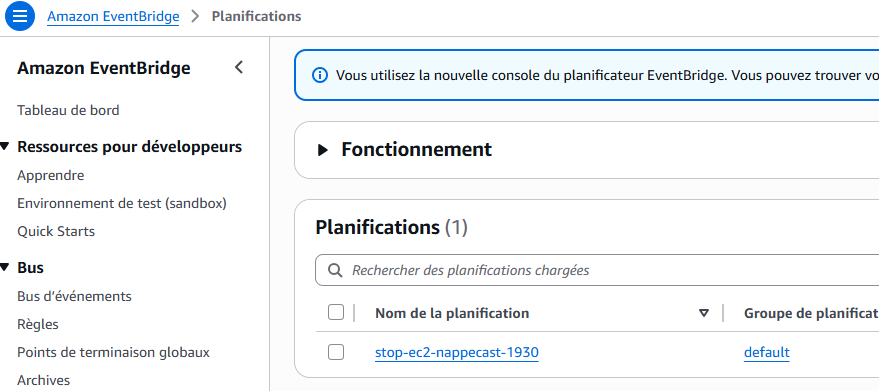

### check de l'IP

In [ ]:
resp = ec2.describe_instances(InstanceIds=[instance_id])
print(resp["Reservations"][0]["Instances"][0]["State"]["Name"])
print(resp["Reservations"][0]["Instances"][0].get("PublicIpAddress"))

sg_id = resp["Reservations"][0]["Instances"][0]["SecurityGroups"][0]["GroupId"]
import requests
current_ip = requests.get("https://checkip.amazonaws.com").text.strip()
print("Ton IP actuelle :", current_ip)

sg = ec2.describe_security_groups(GroupIds=[sg_id])
for perm in sg["SecurityGroups"][0]["IpPermissions"]:
    if perm.get("FromPort") == 22:
        print("IP autorisée pour le SSH :", perm.get("IpRanges"))

### reboot instance

In [ ]:
ec2.reboot_instances(InstanceIds=[instance_id])

### vérification de la santé de l'infra

In [ ]:
resp = ec2.describe_instance_status(InstanceIds=[instance_id])
status = resp["InstanceStatuses"][0]
print("Instance status  :", status["InstanceStatus"]["Status"])
print("System status    :", status["SystemStatus"]["Status"])
print("Détails :", status["InstanceStatus"]["Details"])